# Photometry demonstration.

1. BIAS correction.
2. Flat correction.
3. Cosmic Ray removal.
4. Finding the FWHM for a few sources, to determine the aperture radius.
5. Selecting the source and comparison stars for performing aperture photometry.
6. Conversion of time to Julian Dates (JD) or MJD.
7. Align the images with respect to a reference image (to make sure the co-ordinates are constant throughout the sample)
8. Calculate and subtract the global rms background.
9. Finds the sources in an image based on the DAOFIND algorithm. IRAFStarFinder, which uses IRAF algorithm can also be used.
10. Generates multiple apertures on the locations selected by the user.
11. Generates annulus to estimate the local backgound and subtract it later.
12. Gets the total flux within the apertures and instrumental magnitudes.
13. Estimates the error on the flux and magnitudes assuming poisson noise.
14. Writes the output to ASCII file.
15. Plot the light curves using matplotlib.

In [1]:

!pip install ccdproc
!pip install photutils
!pip install astroquery

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.3/351.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.0/191.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.8/379.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 54.1 MB/s eta 0:00:00
  Created wheel for pims: filename=PIMS-0.7-py3-none-any.whl size=84590 sha256=24c88de722b6b50fbb68d040dbd1c2c4a9e267dfe9eedf9a366bf322673515c2
  Stored in directory: /root/.cache/pip/wheels/be/9c/72/7cb84823aaa980c2e44064caae0ba869239270fac14f71

In [2]:
!git clone https://github.com/viveikjha/photometry_demo/

Cloning into 'photometry_demo'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 29 (delta 1), reused 14 (delta 1), pack-reused 15 (from 1)
Receiving objects: 100% (29/29), 75.64 MiB | 12.46 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (21/21), done.


In [3]:
cd photometry_demo/images

/content/photometry_demo/images


In [4]:
!rm *csv *cleaned.fits

In [ ]:
!ls

B-2022APXX-2022-02-01T12:27:12.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:27:48.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:28:04.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:28:29.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:29:17.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:42:31.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:42:58.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:43:25.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:43:53.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:44:22.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:44:52.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:45:22.000-DFOT-2K_IMG1.fits
S-2022APXX-2022-02-01T18:00:55.911-DFOT-2K_IMG1.fits


In [ ]:
import numpy as np
import matplotlib as mp
import pandas as pd
import math
import re
import matplotlib.pyplot as plt
import ccdproc,os,sys,time,random, csv
from glob import glob
from astropy import units as u
from astropy.io import fits
from astropy.time import Time
from astropy.wcs import WCS
from astropy.nddata import CCDData
from astropy.stats import sigma_clipped_stats, SigmaClip
from astropy.visualization import ImageNormalize, LogStretch, ZScaleInterval
from astropy.stats import SigmaClip, mad_std
from photutils.background import Background2D, MeanBackground,SExtractorBackground
from photutils import find_peaks, CircularAperture, CircularAnnulus, aperture_photometry
from photutils import Background2D, MedianBackground, DAOStarFinder
from photutils.utils import calc_total_error
from astropy.coordinates import SkyCoord, Angle
from astropy import coordinates as coord
from astropy import units as u
import warnings
warnings.filterwarnings("ignore")

<ipython-input-10-e6a69c96656c>:18: DeprecationWarning: `photutils.find_peaks` is a deprecated alias for `photutils.detection.find_peaks` and will be removed in the future. Instead, please use `from photutils.detection import find_peaks` to silence this warning.
  from photutils import find_peaks, CircularAperture, CircularAnnulus, aperture_photometry
<ipython-input-10-e6a69c96656c>:18: DeprecationWarning: `photutils.CircularAperture` is a deprecated alias for `photutils.aperture.CircularAperture` and will be removed in the future. Instead, please use `from photutils.aperture import CircularAperture` to silence this warning.
  from photutils import find_peaks, CircularAperture, CircularAnnulus, aperture_photometry
<ipython-input-10-e6a69c96656c>:18: DeprecationWarning: `photutils.CircularAnnulus` is a deprecated alias for `photutils.aperture.CircularAnnulus` and will be removed in the future. Instead, please use `from photutils.aperture import CircularAnnulus` to silence this warning.



# Cleaning the images

This module is meant for cleaning the images. The tasks to be included are: bias correction, flat correction, trimming, overscan as well as the cosmic ray removal from the science cases. (For the time we are skipping the overscan and trimming part.)

Step 1: Bias correction

Note: this step assumes multiple bias files to generate the mbias. If mbias exists already, skip this block.


In [ ]:
#start = Time.time()
warnings.filterwarnings("ignore")
## We load the bias files here using glob.
bias_files = sorted(glob(os.path.join(f'B-2022*.fits')))
biaslist = []
print(bias_files)
for i in range (len(bias_files)):
    data= ccdproc.CCDData.read(bias_files[i],unit='adu')
        #data = ccdproc.create_deviation(data, gain=gain, readnoise=readnoise)
        #data= data-(data.uncertainty.array)
    #print(data.data.shape)
    biaslist.append(data)
#print(biaslist)
masterbias = ccdproc.combine(biaslist,method='median',sigma_clip=True, sigma_clip_low_thresh=5, sigma_clip_high_thresh=5,
                             sigma_clip_func=np.ma.median, sigma_clip_dev_func=mad_std)
masterbias.write(f'masterbias.fits', overwrite=True)
#mbias=ccdproc.CCDData.read(f'masterbias.fits',unit='adu')
print('Master bias generated')
#print(" Mean and median of the masterbias:", np.mean(masterbias), np.median(masterbias))

#end = time.time()
#print('Execution took:', end - start, 'seconds')

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit NULL in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit NULL in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit NULL in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit NULL in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit NULL in the FITS file.


['B-2022APXX-2022-02-01T12:27:12.000-DFOT-2K_IMG1.fits', 'B-2022APXX-2022-02-01T12:27:48.000-DFOT-2K_IMG1.fits', 'B-2022APXX-2022-02-01T12:28:04.000-DFOT-2K_IMG1.fits', 'B-2022APXX-2022-02-01T12:28:29.000-DFOT-2K_IMG1.fits', 'B-2022APXX-2022-02-01T12:29:17.000-DFOT-2K_IMG1.fits']
INFO: using the unit adu passed to the FITS reader instead of the unit NULL in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit NULL in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit NULL in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit NULL in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit NULL in the FITS file. [astropy.nddata.ccddata]
Master bias generated


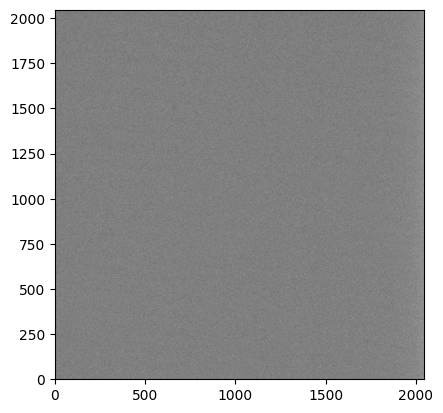

In [ ]:

data=fits.open('masterbias.fits')
header=data[0].header
image=data[0].data
mean,std=np.mean(image),np.std(image)
plt.imshow(image,cmap='gray',origin='lower',vmin=mean-5*std,vmax=mean+5*std)
plt.show()



# Step 2:Flat correction

Note: This step assumes multiple flat files for different bands to generate mflat.fits. If mflat exists, skip this block.


In [ ]:
from astropy.io.fits.verify import VerifyWarning
warnings.simplefilter('ignore', category=VerifyWarning)

flat_files=sorted(glob(os.path.join(f'F-2022*.fits')))
flatlist=[]
for j in range(0,len(flat_files)):
    flat=ccdproc.CCDData.read(flat_files[j],unit='adu')
    mbias=ccdproc.CCDData.read(f'masterbias.fits',unit='adu')
    #print(mbias.data.shape)
    #print(flat.data.shape)
    flat_bias_removed=ccdproc.subtract_bias(flat,mbias) #flat - master bias
    flatlist.append(flat_bias_removed)

def inv_median(a):     # This seems to be a soultion for normalizing the flats.
    return 1 / np.median(a)
#scale=inv_median not used, instead norm_value = np.median(masterflat) used while division

masterflat = ccdproc.combine(flatlist,method='median',scale=inv_median ,sigma_clip=True, sigma_clip_low_thresh=5, sigma_clip_high_thresh=5, sigma_clip_func=np.ma.median, sigma_clip_dev_func=mad_std)
masterflat.write(f'masterflat.fits', overwrite=True)
#mflat=ccdproc.CCDData.read(f'masterflat.fits',unit='adu')
#print('Master flat generated')
#print(" Mean and median of the masterflat: ",np.mean(masterflat), np.median(masterflat))

#end = time.time()
#print('Execution took:', end - start, 'seconds')

In [ ]:
new_flat=ccdproc.combine(flatlist,method='median')
new_flat.write('test_flat_without_scale.fits')

0.9997348555749814 0.028493721133708426


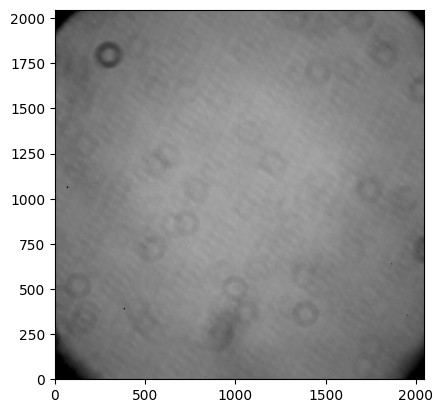

In [ ]:
data=fits.open('masterflat.fits')
header=data[0].header
image=data[0].data
mean,std=np.mean(image),np.std(image)
print(mean,std)
plt.imshow(image,cmap='gray',origin='lower',vmin=mean-5*std,vmax=mean+5*std)
plt.show()

#Step 3:
Final bias, flat correction and cosmic ray removal and saving the cleaned images.

In [ ]:

files=sorted(glob(os.path.join(f'S-2022*.fits')))
for i in range(0,len(files)): #(0,len(files))
    print(files[i])
    image=ccdproc.CCDData.read(files[i],unit='adu')
    header=fits.getheader(files[i],0)
    mbias=ccdproc.CCDData.read(f'masterbias.fits',unit='adu')
    mflat=ccdproc.CCDData.read(f'masterflat.fits',unit='adu')
    if image.data.shape == mbias.data.shape:

        bias_subtracted = ccdproc.subtract_bias(image, mbias)
        flat_corrected = ccdproc.flat_correct(bias_subtracted, mflat)#, norm_value=np.median(masterflat))

        cr_cleaned = ccdproc.cosmicray_lacosmic(flat_corrected,readnoise=10, sigclip=5, verbose=True)
        print('Cosmic rays removed')
        clean_file=files[i].replace('.fits','')

        fits.writeto(clean_file+'_cleaned.fits',cr_cleaned, header=header,overwrite=True)
        x= 1 + i
        print('Image no-%x has been cleaned'%x)
        print(" Mean and median of the masterflat: ",np.mean(cr_cleaned), np.median(cr_cleaned))

end = time.time()
print('Execution took:', end - start, 'seconds')

In [ ]:
!ls

B-2022APXX-2022-02-01T12:27:12.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:27:48.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:28:04.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:28:29.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:29:17.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:42:31.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:42:58.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:43:25.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:43:53.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:44:22.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:44:52.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:45:22.000-DFOT-2K_IMG1.fits
masterbias.fits
masterflat.fits
README.md
S-2022APXX-2022-02-01T18:00:55.911-DFOT-2K_IMG1_cleaned.fits
S-2022APXX-2022-02-01T18:00:55.911-DFOT-2K_IMG1.fits


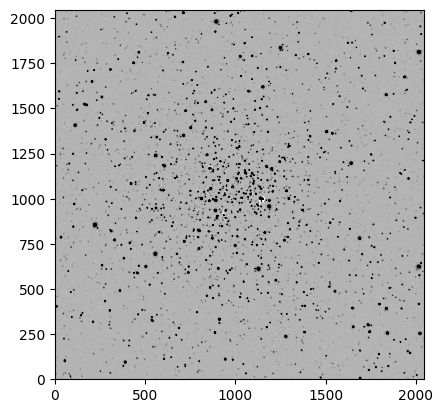

In [ ]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import numpy as np

data=fits.open('S-2022APXX-2022-02-01T18:00:55.911-DFOT-2K_IMG1_cleaned.fits')
header=data[0].header
image=data[0].data
mean,std=np.mean(image),np.std(image)
sigma_clip = SigmaClip(sigma=3, maxiters=10)
bkg_estimator = SExtractorBackground()
bkg = Background2D(image, (10,10), filter_size=(3, 3),sigma_clip=sigma_clip, bkg_estimator=bkg_estimator) # 2D background map
back=bkg.background
plt.imshow(image-back,cmap='gray_r',origin='lower',vmin=mean-0.3*std,vmax=mean+0.3*std)
#print(type(image-back))
#print(np.mean(back),np.std(back))
plt.show()

In [ ]:
def source(data, header):
    sigma_clip = SigmaClip(sigma=3, maxiters=10)
    bkg_estimator = SExtractorBackground()
    bkg = Background2D(data, (10,10), filter_size=(3, 3),sigma_clip=sigma_clip, bkg_estimator=bkg_estimator) # 2D background map
    back=bkg.background
    h = fits.open(filename)
    wcs = WCS(h[0].header)
    mask = data == 0
    unit = u.electron / u.s

    xdf_image = CCDData(data, unit=unit, meta=header, mask=mask)
    norm_image = ImageNormalize(vmin=1e-4, vmax=5e-2, stretch=LogStretch(), clip=False)
    xdf_image_clipped = np.clip(xdf_image, 1e-4, None)

    mean, median, std = sigma_clipped_stats(xdf_image.data, sigma=3.0, maxiters=20, mask=xdf_image.mask)
    daofind = DAOStarFinder(fwhm=4, threshold=5*std)
    return daofind(data - back)#, mean, std


Now, we have the total flux for different apertures. To convert these flux to magnitudes we ca use:

~~~
apparent_magnitude = -2.5log(final_sum) + zp
~~~


where zp is the photometric zero point for a given aperture, calculated from apparent magnitudes of the known sources.

We need to figure out how manu known sources are available in the field, and then get their magnitudes.


In [ ]:
def magnitude(data, header, apertures, an_ap ):
    #print(apertures)
    sigma_clip = SigmaClip(sigma=3, maxiters=10)
    bkg_estimator = SExtractorBackground()
    bkg = Background2D(data, (10,10), filter_size=(3, 3),sigma_clip=sigma_clip, bkg_estimator=bkg_estimator) # 2D background map 2nd time. We will use only once.
    back=bkg.background
    #exposure=header['EXPTIME']
    exposure=5
    effective_gain=exposure # Need to verify this one. Why effective gain= exposure?
    error=calc_total_error(data,back,effective_gain)

    phot_table = aperture_photometry(data, apertures,error=error)
    phot_table2=aperture_photometry(data,an_ap)
    #print(len(phot_table))

    bkg_mean = phot_table2['aperture_sum'] / an_ap.area
    bkg_sum = bkg_mean * an_ap.area


    final_sum0=phot_table['aperture_sum_0']-bkg_sum
    final_sum1=phot_table['aperture_sum_1']-bkg_sum
    final_sum2=phot_table['aperture_sum_2']-bkg_sum
    final_sum3=phot_table['aperture_sum_3']-bkg_sum
    final_sum4=phot_table['aperture_sum_4']-bkg_sum



    mag_back=-2.5*np.log10(bkg_mean/exposure)
    mag_0=-2.5*np.log10(final_sum0/exposure)
    mag_1=-2.5*np.log10(final_sum1/exposure)
    mag_2=-2.5*np.log10(final_sum2/exposure)
    mag_3=-2.5*np.log10(final_sum3/exposure)
    mag_4=-2.5*np.log10(final_sum4/exposure)



    flux_err_0=phot_table['aperture_sum_err_0']
    mag_err_0=1.09*flux_err_0/final_sum0

    flux_err_1=phot_table['aperture_sum_err_1']
    mag_err_1=1.09*flux_err_1/final_sum1

    flux_err_2=phot_table['aperture_sum_err_2']
    mag_err_2=1.09*flux_err_2/final_sum2

    flux_err_3=phot_table['aperture_sum_err_3']
    mag_err_3=1.09*flux_err_3/final_sum3

    flux_err_4=phot_table['aperture_sum_err_4']
    mag_err_4=1.09*flux_err_4/final_sum4



    return mag_0 , mag_err_0 , mag_1 , mag_err_1 , mag_2 , mag_err_2 , mag_3 , mag_err_3 , mag_4 , mag_err_4
#radii = [4,5]
#positions = (source_0['xcentroid'][1], source_0['ycentroid'][1])
#apertures = [CircularAperture(positions, r=4)]#for r in radii]
#an_ap = CircularAnnulus(positions, r_in=14, r_out=14.5)
#magnitude(data_0, apertures,an_ap)

In [ ]:
import pandas as pd
warnings.filterwarnings("ignore")
files=sorted(glob(os.path.join(f'S-2022*cleaned.fits')))
f = 0
filename=files[f]
start = time.time()
data_0,header_0=fits.getdata(files[f],header=True)
print(files[f])
source_0 = source(data_0 , header_0)
print('No. of sources: ',len(source_0))
# print(source_0)
end = time.time()
print('Execution took:',end - start,' seconds')

radii = [5, 6, 7, 8, 9]
positions = [(source_0['xcentroid'][i], source_0['ycentroid'][i]) for i in range(len(source_0))]
apertures = [CircularAperture(positions, r=r) for r in radii] # Can we be flexible with variable apertures?
an_ap = CircularAnnulus(positions, r_in=14, r_out=15) # Is it needed if we get the 2D backgound  map?
#print(type(source_0['xcentroid']))
start = time.time()
mag_0 , mag_err_0 , mag_1 , mag_err_1 , mag_2 , mag_err_2 , mag_3 , mag_err_3 , mag_4 , mag_err_4 = magnitude(data_0, header_0, apertures, an_ap)
jd = header_0['JD']
jd_list = [jd] * len(source_0['xcentroid'])
h = fits.open(files[f])
wcs = WCS(h[0].header)
ra , dec = wcs.all_pix2world(source_0['xcentroid'],source_0['ycentroid'],0)
#print(data_0, header_0, apertures, an_ap)
print(ra, dec)
#print(len(positions))

#data = np.array([jd_list, ra,dec, mag_0, mag_err_0, mag_1, mag_err_1, mag_2, mag_err_2, mag_3, mag_err_3, mag_4, mag_err_4])
#transposed_data = np.transpose(data)

with open(f"zipped_data_{f}.csv", 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['JD', 'RA', 'DEC', 'Magnitude0', 'Magnitude_error0', 'Magnitude1', 'Magnitude_error1', 'Magnitude2', 'Magnitude_error2', 'Magnitude3', 'Magnitude_error3', 'Magnitude4', 'Magnitude_error4' ])
    writer.writerows(zip(jd_list, ra,dec, mag_0 , mag_err_0 , mag_1 , mag_err_1 , mag_2 , mag_err_2 , mag_3 , mag_err_3 , mag_4 , mag_err_4 ))

end = time.time()
print('Execution took:', end - start, 'seconds')
# plt.imshow(data_0,cmap='gray',origin='lower',vmin=mean-5*std,vmax=mean+5*std)
# print(type(data_0))

# output = pd.DataFrame({'JD' : jd_list , 'RA' :ra , 'DEC': dec, 'Magnitude0':mag_0, 'Magnitude_error0':mag_err_0 , 'Magnitude1': mag_1, 'Magnitude_error1' : mag_err_1, 'Magnitude2' :mag_2, 'Magnitude_error2' :mag_err_2, 'Magnitude3':mag_3, 'Magnitude_error3': mag_err_3, 'Magnitude4':mag_4, 'Magnitude_error4':mag_err_4})
# output_to.csv("Trial11.csv")

S-2022APXX-2022-02-01T18:00:55.911-DFOT-2K_IMG1_cleaned.fits
No. of sources:  2357
Execution took: 10.050963163375854  seconds
[119.86270179 120.14822066 119.90322545 ... 120.09695576 119.92648914
 120.08465527] [-10.92893882 -10.92532046 -10.92792436 ... -10.61980095 -10.62134395
 -10.61900033]
Execution took: 8.40915584564209 seconds


# Curve of growth for optimum aperture

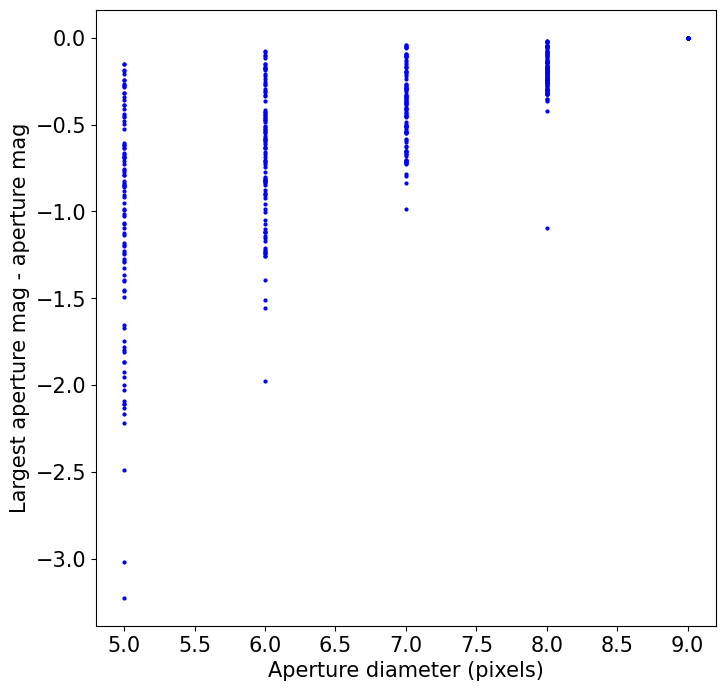

Execution took:  1.6993041038513184  seconds


In [ ]:
warnings.filterwarnings("ignore")
x=radii
start = time.time()
plt.figure(figsize = (8,8))
for i in range(0,100):
    y=[]
    y.append(mag_4[i]-mag_0[i])
    y.append(mag_4[i]-mag_1[i])
    y.append(mag_4[i]-mag_2[i])
    y.append(mag_4[i]-mag_3[i])
    y.append(mag_4[i]-mag_4[i])

    plt.plot(x,y, 'bo',markersize=2)
    plt.xlabel('Aperture diameter (pixels)', fontsize=15)
    plt.ylabel('Largest aperture mag - aperture mag', fontsize = 15)
#     plt.ylim(-0.5,0.5)
    plt.xticks(fontsize = 15)
    plt.yticks(fontsize = 15)
plt.show()

end = time.time()
print('Execution took: ',end - start,' seconds')

In [ ]:
!ls

B-2022APXX-2022-02-01T12:27:12.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:27:48.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:28:04.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:28:29.000-DFOT-2K_IMG1.fits
B-2022APXX-2022-02-01T12:29:17.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:42:31.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:42:58.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:43:25.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:43:53.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:44:22.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:44:52.000-DFOT-2K_IMG1.fits
F-2022APXX-2022-02-01T12:45:22.000-DFOT-2K_IMG1.fits
masterbias.fits
masterflat.fits
README.md
S-2022APXX-2022-02-01T18:00:55.911-DFOT-2K_IMG1_cleaned.fits
S-2022APXX-2022-02-01T18:00:55.911-DFOT-2K_IMG1.fits
zipped_data_0.csv


In [ ]:
#SIMBAD CODE

import astropy.units as u
import csv
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
start = time.time()
warnings.filterwarnings("ignore")


# Read RA and DEC from the text file
star_coordinates = []
with open(f"zipped_data_0.csv", 'r') as file: #
    reader = csv.reader(file)
    next(reader)  # Skip the header row
    for row in reader:
        ra, dec = row[1], row[2]
        star_coordinates.append((float(ra), float(dec)))


# Query Simbad for magnitudes of stars
Simbad.reset_votable_fields()
Simbad.add_votable_fields('flux(R)', 'flux_error(R)')

ra_list = []
dec_list = []
magnitude_list = []
magnitude_error_list = []
print('reached 1')
for ra, dec in star_coordinates:
    coords = SkyCoord(ra=ra, dec=dec, unit=u.deg, frame='icrs')
    result_table = Simbad.query_region(coords, radius=5 * u.arcsec)
    if result_table is not None:
        magnitude = result_table['FLUX_R'][0]
        magnitude_error = result_table['FLUX_ERROR_R'][0]
        ra_list.append(ra)
        dec_list.append(dec)
        magnitude_list.append(magnitude)
        magnitude_error_list.append(magnitude_error)
    else:
        ra_list.append(ra)
        dec_list.append(dec)
        magnitude_list.append('Notfound')
        magnitude_error_list.append('Notfound')

    print('done')
print('reached 2')

# Save the retrieved magnitudes to a .csv file
output_file = f"simbad_magnitudes.csv"
with open(output_file, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['RA', 'DEC', 'Magnitude', 'Magnitude_error'])
    writer.writerows(zip(ra_list, dec_list, magnitude_list, magnitude_error_list))

print(f"Star magnitudes saved to '{output_file}'.")
end = time.time()
print('Execution took: ',end - start,' seconds')

reached 1
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done
done


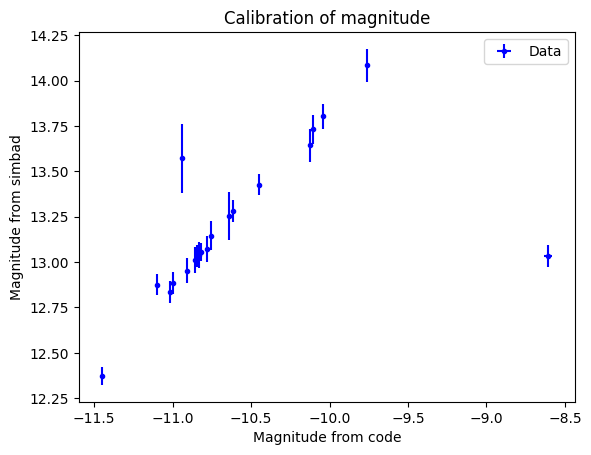

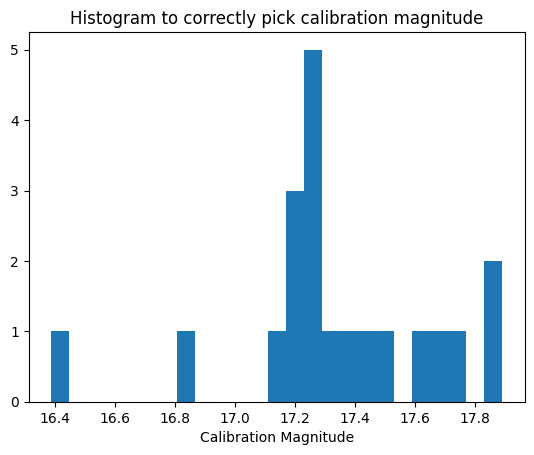

In [ ]:
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV files
file1 = pd.read_csv(f"zipped_data_0.csv") #reference frame file
file2 = pd.read_csv(f'simbad_magnitudes.csv') #simbad code generated file

# Extract the desired columns
x_values0 = file1['Magnitude0']  # Replace 'desired_column_name' with the actual column name from file1
x_error0 = file1['Magnitude_error0']
y_values = file2['Magnitude']  # Assuming the third column in file2 is named 'Column3'
y_error = file2['Magnitude_error']  # Assuming the fourth column in file2 is named 'Column4'

x_values1 = file1['Magnitude1']  # Replace 'desired_column_name' with the actual column name from file1
x_error1 = file1['Magnitude_error1']
x_values2 = file1['Magnitude2']  # Replace 'desired_column_name' with the actual column name from file1
x_error2 = file1['Magnitude_error2']
x_values3 = file1['Magnitude3']  # Replace 'desired_column_name' with the actual column name from file1
x_error3 = file1['Magnitude_error3']
x_values4 = file1['Magnitude4']  # Replace 'desired_column_name' with the actual column name from file1
x_error4 = file1['Magnitude_error4']
# Convert y_values and y_error to numeric, handling invalid or missing values
y_values = pd.to_numeric(y_values, errors='coerce')
y_error = pd.to_numeric(y_error, errors='coerce')

# Filter out invalid or missing values from x_values, y_values, and y_error
valid_indices = (~np.isnan(x_values0)) & (~np.isnan(y_values)) & (~np.isnan(y_error))
x_values0 = x_values0[valid_indices]
x_values1 = x_values1[valid_indices]
x_values2 = x_values2[valid_indices]
x_values3 = x_values3[valid_indices]
x_values4 = x_values4[valid_indices]
y_values = y_values[valid_indices]
y_error = y_error[valid_indices]
x_error0 = x_error0[valid_indices]
x_error1 = x_error1[valid_indices]
x_error2 = x_error2[valid_indices]
x_error3 = x_error3[valid_indices]
x_error4 = x_error4[valid_indices]
# Plotting
# plt.errorbar(x_values0, y_values,xerr=x_error0, yerr=y_error, fmt='.', )
# plt.errorbar(x_values1, y_values,xerr=x_error1, yerr=y_error, fmt='.', )
plt.errorbar(x_values2, y_values,xerr=x_error2, yerr=y_error, color='blue',fmt='.', label='Data')
# plt.errorbar(x_values3, y_values,xerr=x_error3, yerr=y_error, fmt='.', )
# plt.errorbar(x_values4, y_values,xerr=x_error4, yerr=y_error, fmt='.',)

# Calculate the best-fit line parameters
# slope0, intercept0 = np.polyfit(x_values0, y_values, 1)
# best_fit_line0 = slope0 * x_values0 + intercept0

# Plot the best-fit line
# plt.plot(x_values0, best_fit_line0, color='r', label='Best Fit Line 0')
# equation0 = f'y = {slope0:.2f}x + {intercept0:.2f}'

# slope1, intercept1 = np.polyfit(x_values1, y_values, 1)
# best_fit_line1 = slope1 * x_values1 + intercept1

# # Plot the best-fit line
# plt.plot(x_values1, best_fit_line1, color='g', label='Best Fit Line 1')
# equation1 = f'y = {slope1:.2f}x + {intercept1:.2f}'

slope2, intercept2 = np.polyfit(x_values2, y_values, 1)
best_fit_line2 = slope2 * x_values2 + intercept2

# Plot the best-fit line
#plt.plot(x_values2, best_fit_line2, color='blue', label='Best Fit Line 2')
equation2 = f'y = {slope2:.2f}x + {intercept2:.2f}'

# slope3, intercept3 = np.polyfit(x_values3, y_values, 1)
# best_fit_line3 = slope3 * x_values3 + intercept3

# # Plot the best-fit line
# plt.plot(x_values3, best_fit_line3, color='black', label='Best Fit Line 3')
# equation3 = f'y = {slope3:.2f}x + {intercept3:.2f}'

# slope4, intercept4 = np.polyfit(x_values4, y_values, 1)
# best_fit_line4 = slope4 * x_values4 + intercept4

# # Plot the best-fit line
# plt.plot(x_values4, best_fit_line4, color='purple', label='Best Fit Line 4')
# equation4 = f'y = {slope4:.2f}x + {intercept4:.2f}'


# Add equation annotation to the plot
# plt.text(0.5, 0.95, equation0, color = 'r',ha='center', va='center', transform=plt.gca().transAxes)
# plt.text(0.5, 0.9, equation1,color = 'g', ha='center', va='center', transform=plt.gca().transAxes)
#plt.text(0.5, 0.85, equation2,color = 'blue', ha='center', va='center', transform=plt.gca().transAxes)
# plt.text(0.5, 0.8, equation3, color = 'black',ha='center', va='center', transform=plt.gca().transAxes)
# plt.text(0.5, 0.75, equation4,color = 'purple', ha='center', va='center', transform=plt.gca().transAxes)

plt.xlabel('Magnitude from code')  # Replace with the desired X axis label
plt.ylabel('Magnitude from simbad')  # Replace with the desired Y axis label
plt.title('Calibration of magnitude')  # Replace with the desired plot title
plt.legend()
plt.show()
#print(x_values2*0.89)
mag=y_values - (x_values2*0.39)
#print(mag)
#print(len(y_values))
plt.hist(mag, bins=25)
plt.xlabel('Calibration Magnitude')
plt.title('Histogram to correctly pick calibration magnitude')
#plt.axvline(x=16.88, color='r', linestyle='--', label='x=17.00')

plt.show()

In [ ]:
def magnitude(data, header, apertures, an_ap ):
    #print(apertures)
    sigma_clip = SigmaClip(sigma=3, maxiters=10)
    bkg_estimator = SExtractorBackground()
    bkg = Background2D(data, (10,10), filter_size=(3, 3),sigma_clip=sigma_clip, bkg_estimator=bkg_estimator) # 2D background map 2nd time. We will use only once.
    back=bkg.background
    #exposure=header['EXPTIME']
    exposure=5
    effective_gain=exposure # Need to verify this one. Why effective gain= exposure?
    error=calc_total_error(data,back,effective_gain)

    phot_table = aperture_photometry(data, apertures,error=error)
    phot_table2=aperture_photometry(data,an_ap)
    #print(len(phot_table))

    bkg_mean = phot_table2['aperture_sum'] / an_ap.area
    bkg_sum = bkg_mean * an_ap.area


    final_sum0=phot_table['aperture_sum_0']-bkg_sum
    # final_sum1=phot_table['aperture_sum_1']-bkg_sum
    #final_sum2=phot_table['aperture_sum_2']-bkg_sum
    # final_sum3=phot_table['aperture_sum_3']-bkg_sum
    # final_sum4=phot_table['aperture_sum_4']-bkg_sum



    mag_back=-2.5*np.log10(bkg_mean/exposure)
    mag_0=-2.5*np.log10(final_sum0/exposure)
    # mag_1=-2.5*np.log10(final_sum1/exposure)
    #mag_2=-2.5*np.log10(final_sum2/exposure)
    # mag_3=-2.5*np.log10(final_sum3/exposure)
    # mag_4=-2.5*np.log10(final_sum4/exposure)



    flux_err_0=phot_table['aperture_sum_err_0']
    mag_err_0=1.09*flux_err_0/final_sum0

    # flux_err_1=phot_table['aperture_sum_err_1']
    # mag_err_1=1.09*flux_err_1/final_sum1

    #flux_err_2=phot_table['aperture_sum_err_2']
    #mag_err_2=1.09*flux_err_2/final_sum2

    # flux_err_3=phot_table['aperture_sum_err_3']
    # mag_err_3=1.09*flux_err_3/final_sum3

    # flux_err_4=phot_table['aperture_sum_err_4']
    # mag_err_4=1.09*flux_err_4/final_sum4



    return mag_0 , mag_err_0 #, mag_1 , mag_err_1 , mag_2 , mag_err_2 , mag_3 , mag_err_3 , mag_4 , mag_err_4
#radii = [4,5]
#positions = (source_0['xcentroid'][1], source_0['ycentroid'][1])
#apertures = [CircularAperture(positions, r=4)]#for r in radii]
#an_ap = CircularAnnulus(positions, r_in=14, r_out=14.5)
#magnitude(data_0, apertures,an_ap)

In [ ]:
warnings.filterwarnings("ignore")
files=sorted(glob(os.path.join(f'S-2022*cleaned.fits')))
f = 0
filename=files[f]
start = time.time()
data_0,header_0=fits.getdata(files[f],header=True)
print(files[f])
source_0 = source(data_0 , header_0)
print('No. of sources: ',len(source_0))
end = time.time()
print('Execution took: ',end - start,' seconds')

intercept= 17

radii = [7]
positions = [(source_0['xcentroid'][i], source_0['ycentroid'][i]) for i in range(len(source_0))]
apertures = [CircularAperture(positions, r=r) for r in radii]
an_ap = CircularAnnulus(positions, r_in=14, r_out=15)

start = time.time()
mag_0, mag_err_0 = magnitude(data_0, header_0, apertures, an_ap)
calibrated_mag = mag_0 + intercept
jd = header_0['JD']
jd_list = [jd] * len(source_0['xcentroid'])
h = fits.open(files[f])
wcs = WCS(h[0].header)
ra , dec = wcs.all_pix2world(source_0['xcentroid'],source_0['ycentroid'],0)
print(ra, dec)
data = np.array([jd_list, ra,dec, mag_0, mag_err_0])
transposed_data = np.transpose(data)

with open(f"Calibrated_zipped_data_{f}.csv", 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['JD', 'RA', 'DEC', 'Calibrated_Magnitude', 'Magnitude_error0'])
    writer.writerows(zip(jd_list, ra,dec, calibrated_mag, mag_err_0))

end = time.time()
print('Execution took:', end - start, 'seconds')
#Don't forget to paste the path of folder in open loop
#Run source definition and the magnitude # but in magnitude keep only one magnitude for all and convert the rest as comment.

S-2022APXX-2022-02-01T18:00:55.911-DFOT-2K_IMG1_cleaned.fits
No. of sources:  2357
Execution took:  6.068002700805664  seconds
[119.86270179 120.14822066 119.90322545 ... 120.09695576 119.92648914
 120.08465527] [-10.92893882 -10.92532046 -10.92792436 ... -10.61980095 -10.62134395
 -10.61900033]
Execution took: 3.9003889560699463 seconds


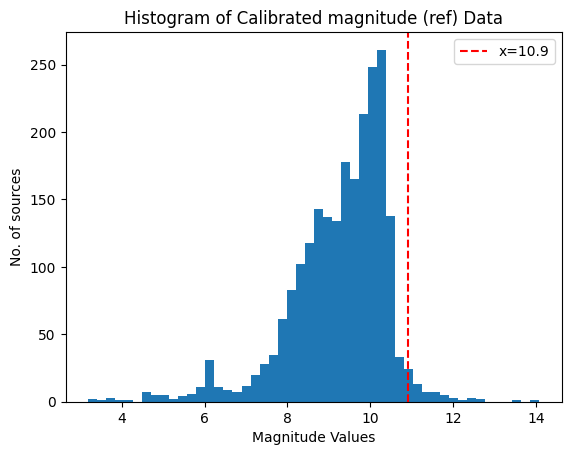

In [ ]:
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
data = pd.read_csv(f'Calibrated_zipped_data_0.csv')

# Extract the data from the 3rd column
column_3_data = data['Calibrated_Magnitude']  # Replace 'Column3' with the actual column name from your CSV file

# Plotting the histogram
plt.hist(column_3_data, bins=50)  # You can adjust the number of bins as per your preference
#plt.axvline(x=10.9, color='r', linestyle='--', label='x=10.9')
# Add labels and title to the plot
plt.xlabel('Magnitude Values')  # Replace with the desired label for the x-axis
plt.ylabel('No. of sources')  # Replace with the desired label for the y-axis
plt.title('Histogram of Calibrated magnitude (ref) Data')  # Replace with the desired title for the plot
plt.legend()
# Display the histogram
plt.show()